In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

prsa_data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.2%20numeric%20features/data/PRSA_Data.csv')
prsa_data = prsa_data.drop(['Unnamed: 0'], axis=1)
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


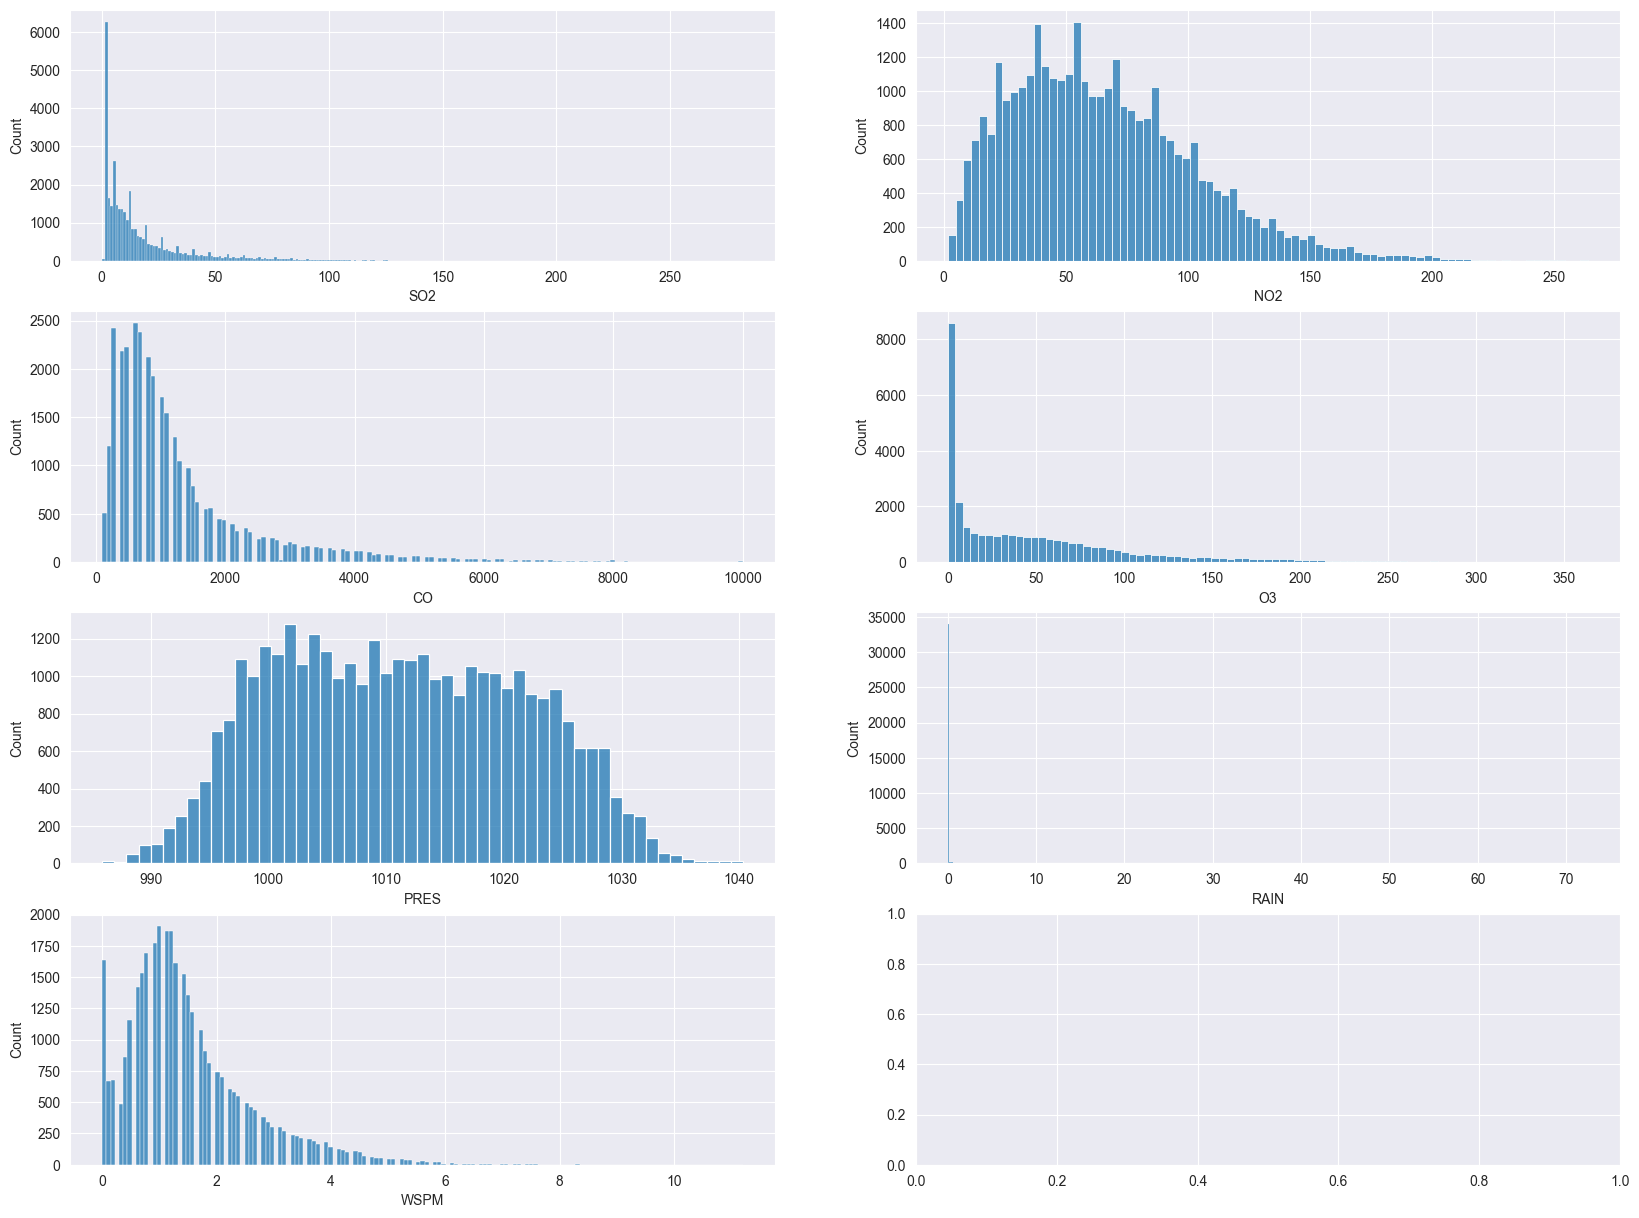

In [99]:
fig, ax = plt.subplots(4, 2, figsize=(20, 15))
ax = ax.flatten()

for n, col in enumerate(prsa_data.drop('wd', axis=1).columns[1:-1]):
    sns.histplot(prsa_data[col], ax=ax[n])
plt.show()

In [100]:
is_rain = np.array(prsa_data['RAIN'])
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop('RAIN', axis=1, inplace=True)
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN
0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0
1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0
2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0
3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0
4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0


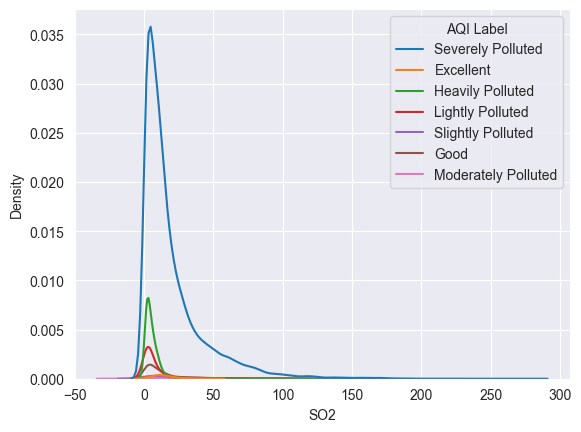

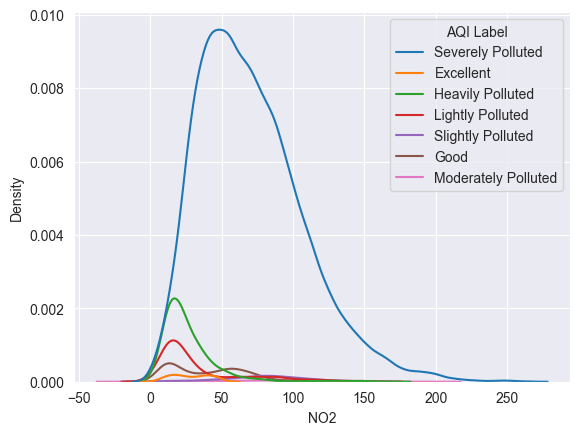

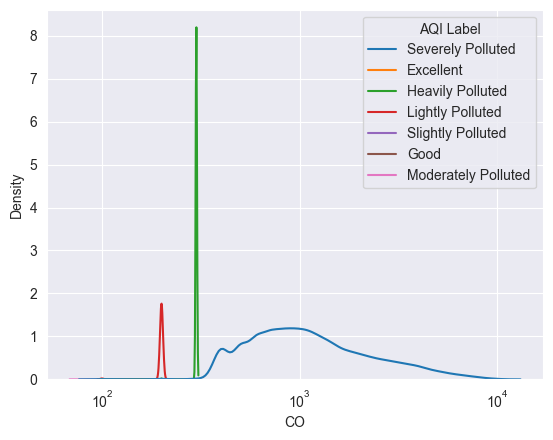

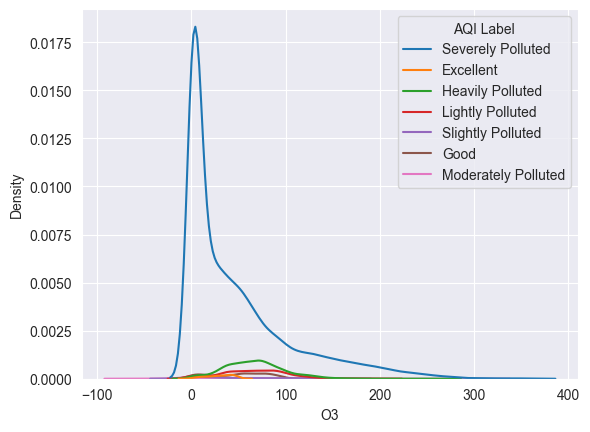

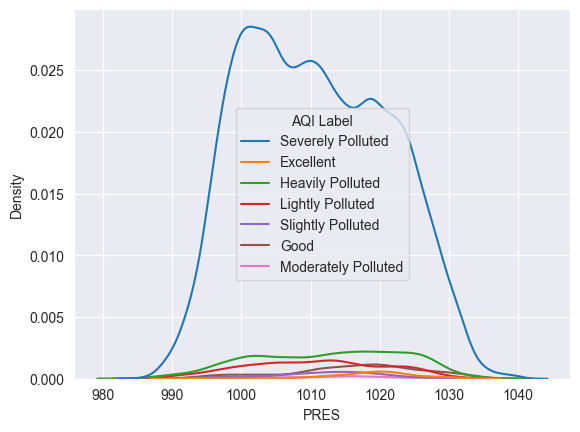

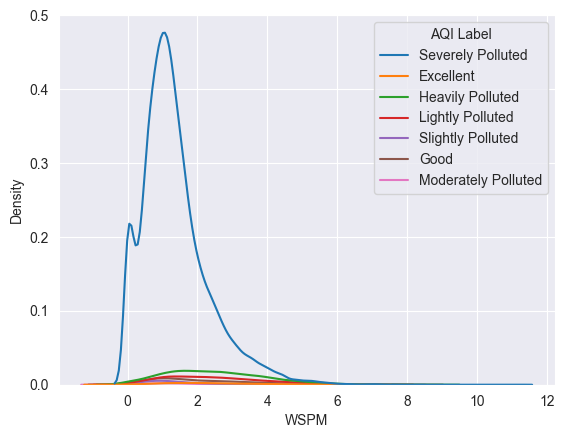

In [101]:
sns.kdeplot(prsa_data, x='SO2', hue='AQI Label')
plt.show()
sns.kdeplot(prsa_data, x='NO2', hue='AQI Label')
plt.show()
sns.kdeplot(prsa_data, x='CO', hue='AQI Label', warn_singular=False, log_scale=True)
plt.show()
sns.kdeplot(prsa_data, x='O3', hue='AQI Label', warn_singular=False)
plt.show()
sns.kdeplot(prsa_data, x='PRES', hue='AQI Label', warn_singular=False)
plt.show()
sns.kdeplot(prsa_data, x='WSPM', hue='AQI Label', warn_singular=False)
plt.show()

In [102]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin'] = pd.cut(np.array(prsa_data['CO']), bins=bin_ranges, labels=bin_names)
prsa_data['CO_bin'] = prsa_data['CO_bin'].values.add_categories(0)
prsa_data['CO_bin'] = prsa_data['CO_bin'].fillna(0).astype(int)
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin
0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [103]:
# prsa_data.PRES[prsa_data.PRES <= 992] = 992
# prsa_data.PRES[prsa_data.PRES >= 1034] = 1034
# sns.histplot(prsa_data['PRES'])
# plt.show()

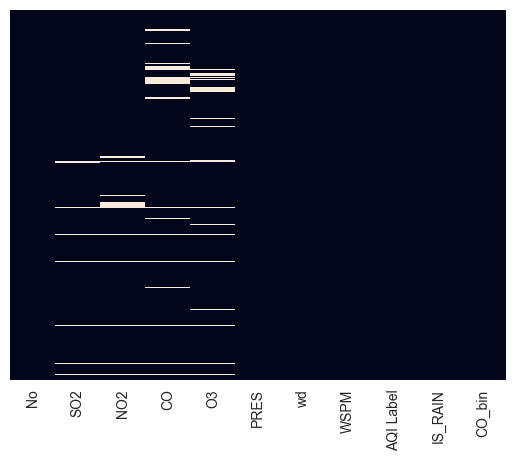

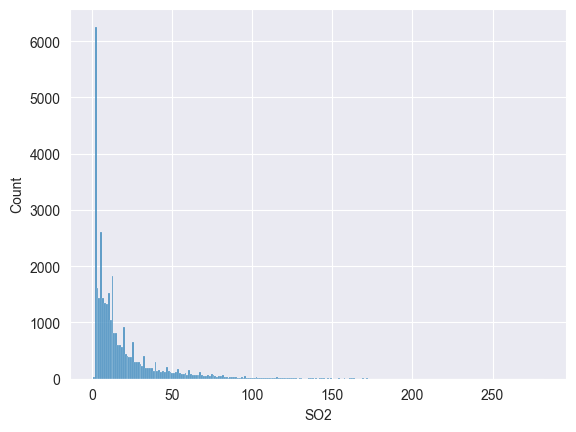

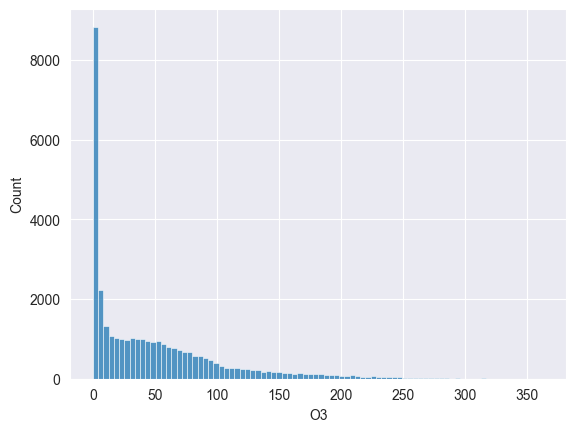

In [104]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)
plt.show()
undef = prsa_data.isnull().sum(axis=1)
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.SO2.median())
sns.histplot(prsa_data['SO2'])
plt.show()
filler = prsa_data.O3[prsa_data.O3.isna()]
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)
prsa_data.O3 = prsa_data.O3.fillna(filler)
sns.histplot(prsa_data['O3'])
plt.show()

<Axes: xlabel='SO2', ylabel='Count'>

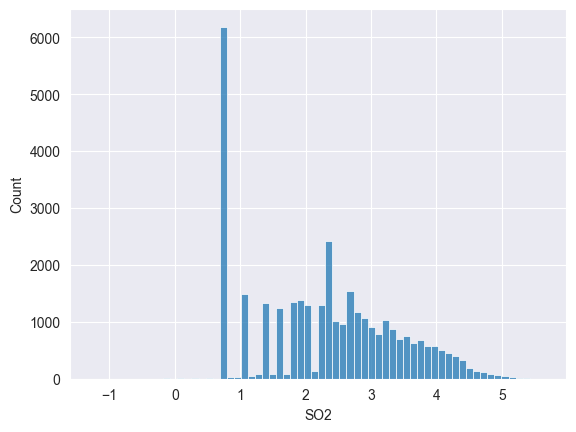

In [105]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.SO2 = np.log(prsa_data.SO2)
sns.histplot(prsa_data['SO2'])

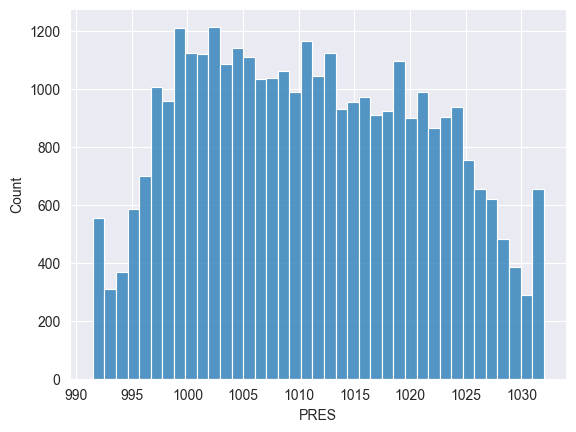

In [106]:
def clipping(df, cols, lower=0.01, upper=0.99):
    df_clipped = df.copy()
    for col in cols:
        low = df[col].quantile(lower)
        high = df[col].quantile(upper)
        df_clipped[col] = df[col].clip(low, high)
    return df_clipped

prsa_data = clipping(prsa_data, ['PRES'])
sns.histplot(prsa_data['PRES'])
plt.show()

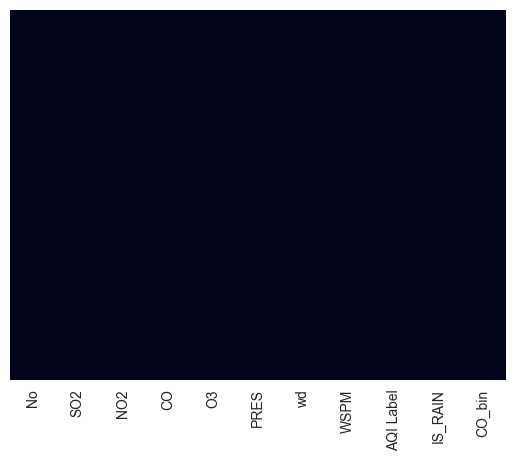

In [108]:
for col in prsa_data.select_dtypes(include='number').columns:
    prsa_data[col].fillna(prsa_data[col].median(), inplace=False)

sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)
plt.show()

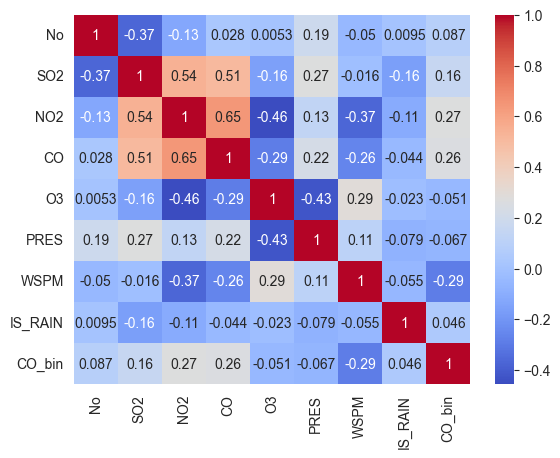

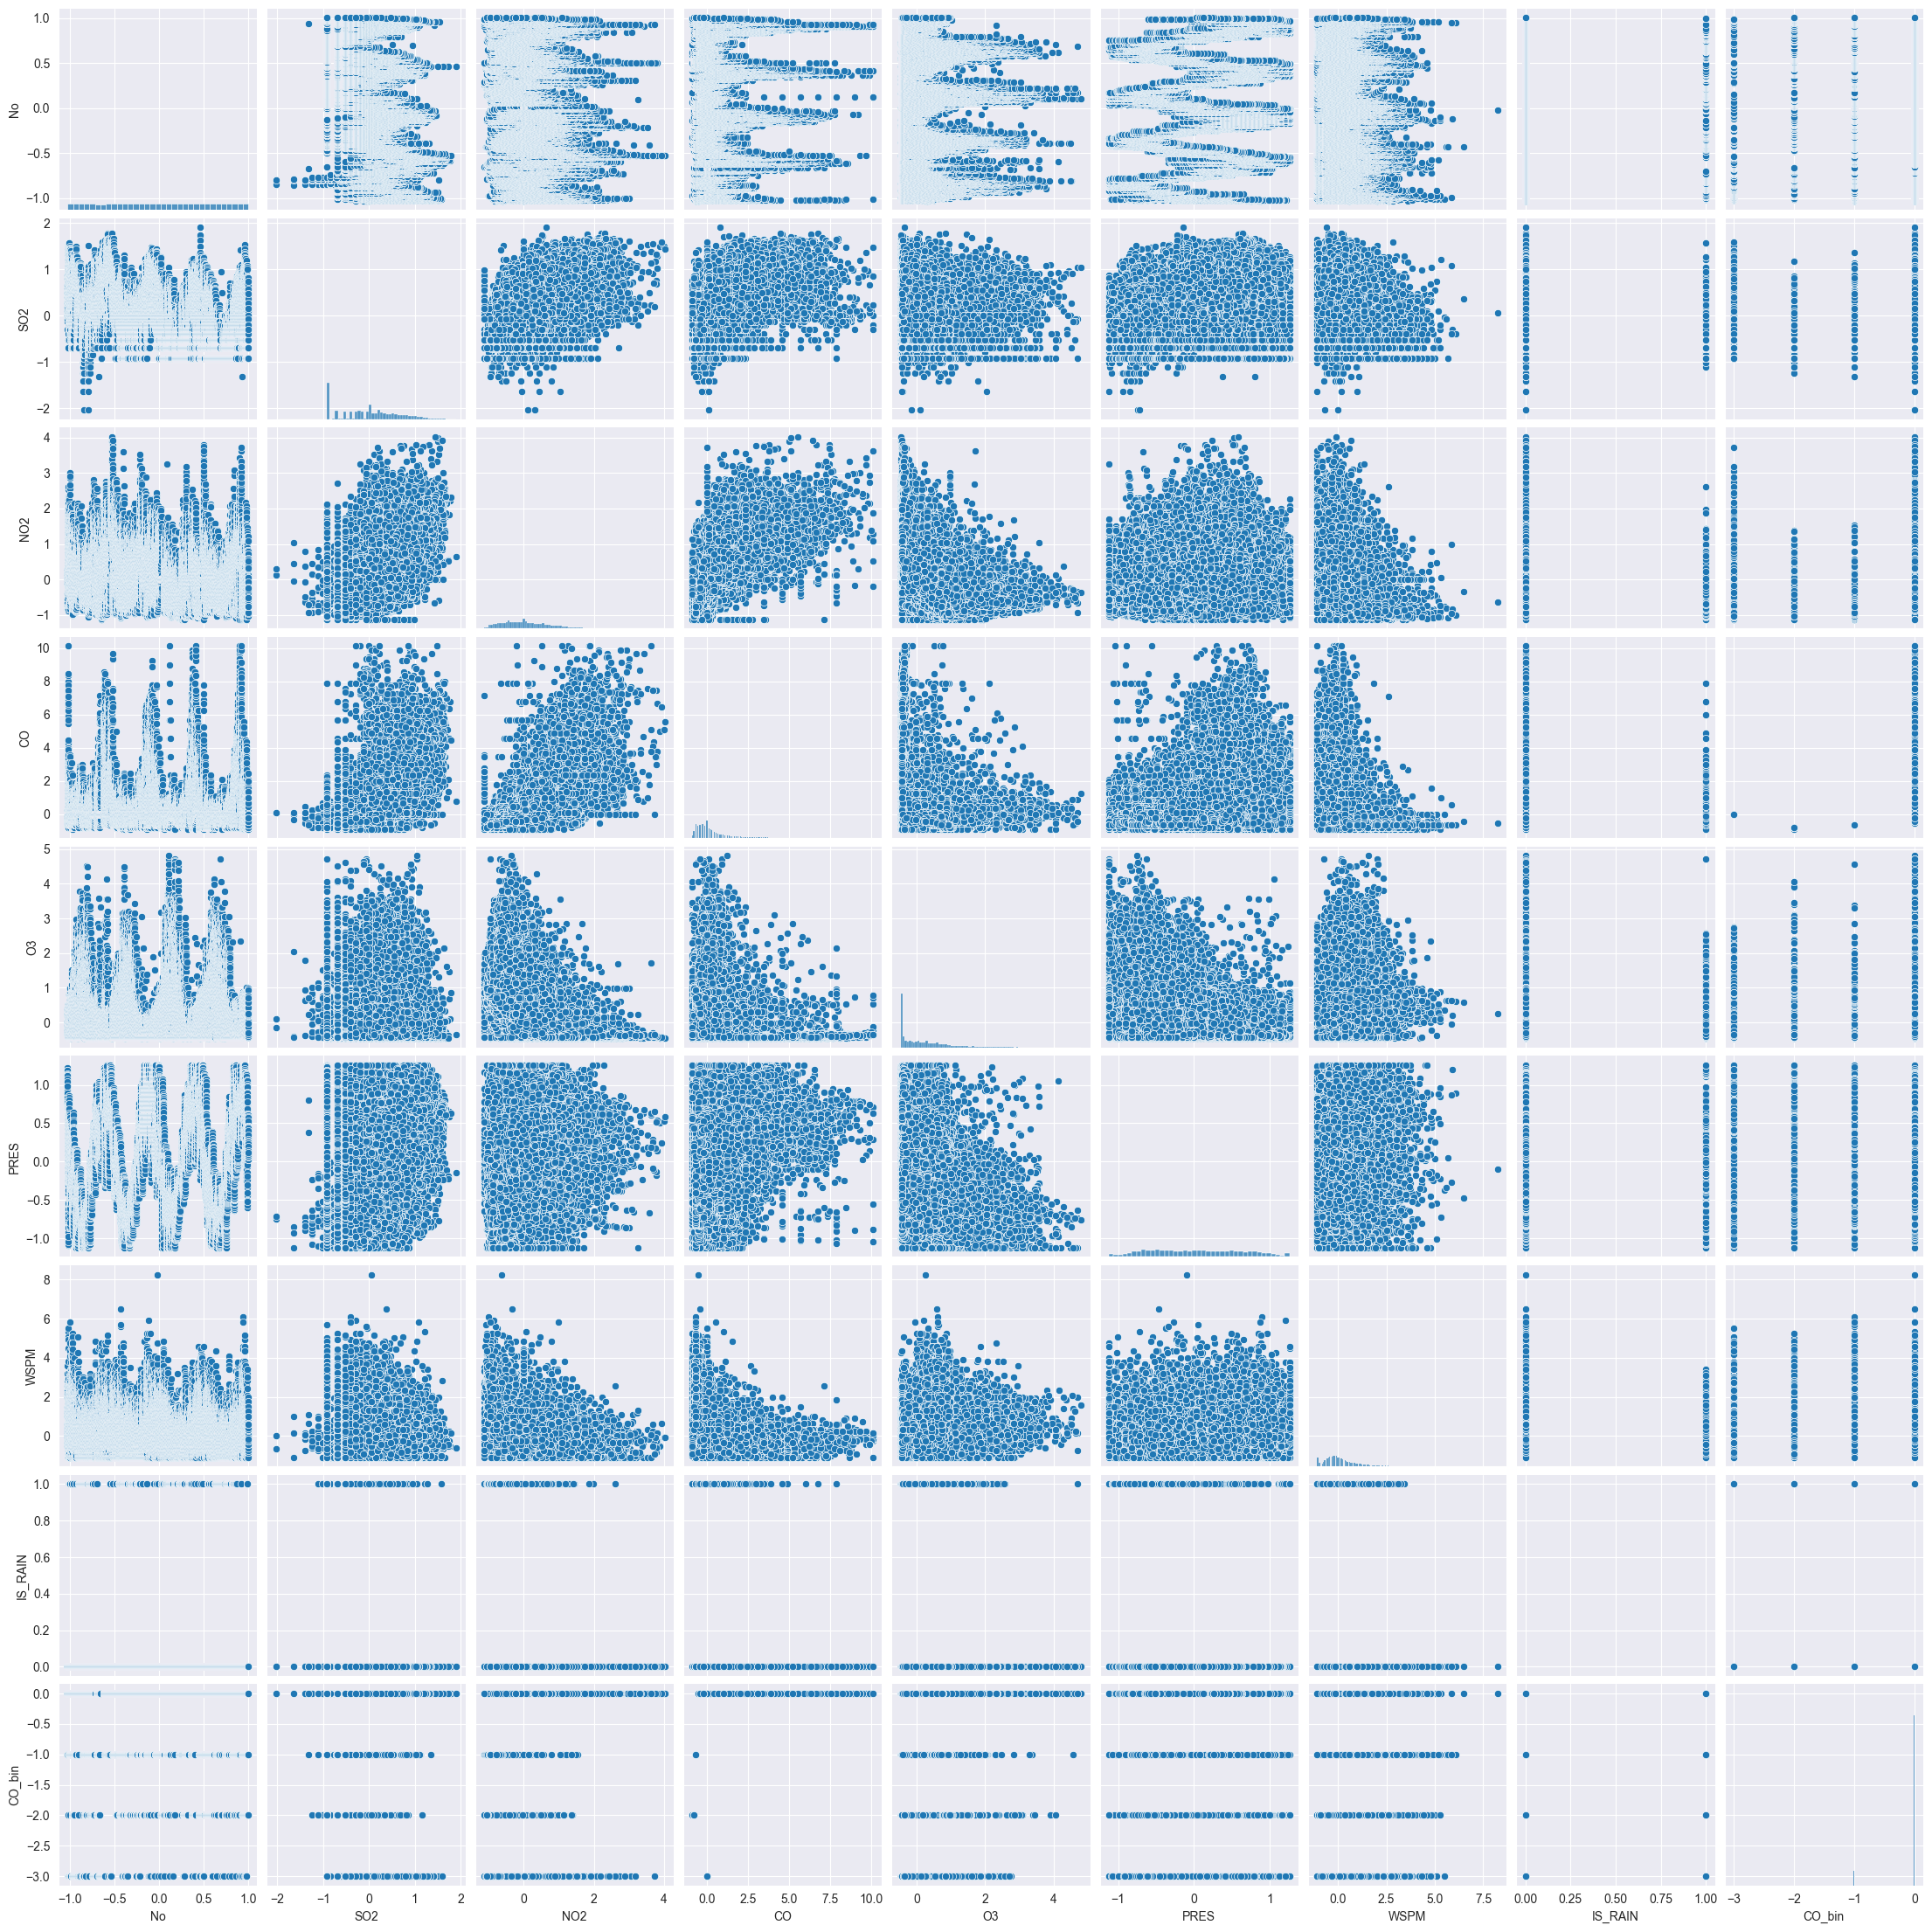

In [111]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
num_cols = prsa_data.select_dtypes(include='number').columns
prsa_data[num_cols] = scaler.fit_transform(prsa_data[num_cols])
correlation = prsa_data.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()
sns.pairplot(prsa_data[num_cols])
plt.show()